# Marketing Mix Modeling

# Phase 4

## Adstock Selection

Objective

Estimate the optimal carryover (adstock) parameter independently for each marketing channel.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("../src").resolve()))

import pandas as pd
import matplotlib.pyplot as plt

from adstock import find_best_decay

In [2]:
cleaned_data = pd.read_csv(
    "../data/processed/raw_data_cleaned.csv"
)

cleaned_data.head()

,State,Week,Salesforce,Email,Website,TV,Meta,Instagram,Influencer,Year,Month,Quarter,Week_Number,Month_End,Quarter_End,Festival,Holiday,Sales
0,Andhra Pradesh,2023-01-02,496.0,13205.0,76588.0,495.0,522380.0,1020933.0,19.0,2023,1,1,1,False,False,1,1,564
1,Andhra Pradesh,2023-01-09,2003.0,11825.0,28198.0,500.0,893916.0,1127800.0,4.0,2023,1,1,2,False,False,1,1,720
2,Andhra Pradesh,2023-01-16,1740.0,4652.0,57482.0,404.0,1433245.0,1422521.0,23.0,2023,1,1,3,False,False,1,1,833
3,Andhra Pradesh,2023-01-23,1265.0,27191.0,92730.0,226.0,1886417.0,1309921.0,23.0,2023,1,1,4,False,False,1,1,880
4,Andhra Pradesh,2023-01-30,1253.0,16403.0,45363.0,408.0,1486410.0,1110026.0,25.0,2023,1,1,5,True,False,1,1,870


In [3]:
channels = [
    "Salesforce",
    "Email",
    "Website",
    "TV",
    "Meta",
    "Instagram",
    "Influencer"
]

In [4]:
salesforce_results = find_best_decay(
    cleaned_data,
    "Salesforce"
)

salesforce_results

,Decay,R2,Adjusted_R2,RMSE,MAE,AIC,BIC
18,0.90,0.862847,0.862816,136.595855,91.465695,43234.497902,43247.274803
17,0.85,0.862300,0.862268,136.868259,96.126418,43252.013744,43264.790645
16,0.80,0.850091,0.850057,142.806794,103.216992,43625.443192,43638.220093
15,0.75,0.833486,0.833449,150.508254,110.852063,44087.245619,44100.022519
14,0.70,0.814740,0.814698,158.754443,118.750403,44556.217025,44568.993925
19,0.95,0.812987,0.812945,159.503727,101.600785,44597.615594,44610.392495
13,0.65,0.794753,0.794706,167.099141,126.470696,45006.619506,45019.396407
12,0.60,0.773942,0.773891,175.365936,134.115426,45431.163714,45443.940615
11,0.55,0.752528,0.752472,183.484025,141.694188,45829.025936,45841.802837
10,0.50,0.730639,0.730578,191.426773,149.206965,46201.611023,46214.387924


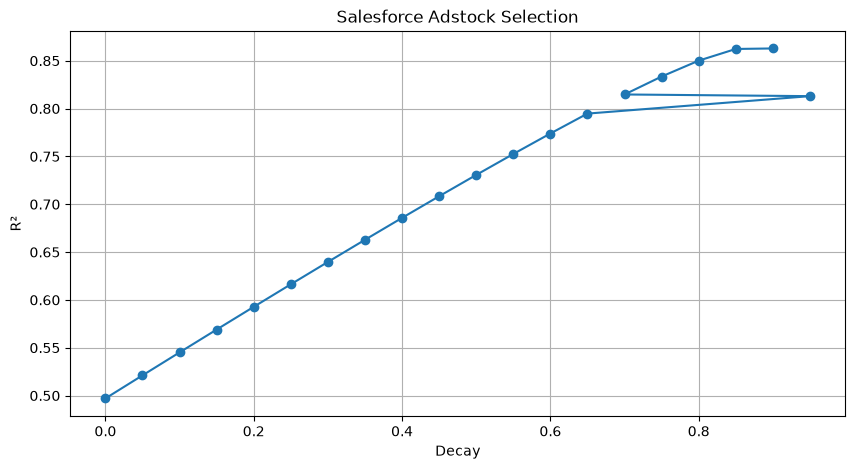

In [5]:
plt.figure(figsize=(10,5))

plt.plot(
    salesforce_results["Decay"],
    salesforce_results["R2"],
    marker="o"
)

plt.xlabel("Decay")

plt.ylabel("R²")

plt.title("Salesforce Adstock Selection")

plt.grid(True)

plt.show()

In [6]:
salesforce_results.iloc[0]

Decay              0.900000
R2                 0.862847
Adjusted_R2        0.862816
RMSE             136.595855
MAE               91.465695
AIC            43234.497902
BIC            43247.274803
Name: 18, dtype: float64

In [7]:
best_adstock = []

all_results = {}

for channel in channels:

    print(f"Evaluating {channel}...")

    results = find_best_decay(
        cleaned_data,
        channel
    )

    all_results[channel] = results

    best = results.iloc[0]

    best_adstock.append({

        "Channel": channel,

        "Best_Decay": best["Decay"],

        "R2": best["R2"],

        "Adjusted_R2": best["Adjusted_R2"],

        "RMSE": best["RMSE"],

        "MAE": best["MAE"],

        "AIC": best["AIC"],

        "BIC": best["BIC"]

    })

best_adstock = pd.DataFrame(best_adstock)

best_adstock

Evaluating Salesforce...
Evaluating Email...
Evaluating Website...
Evaluating TV...
Evaluating Meta...
Evaluating Instagram...
Evaluating Influencer...


,Channel,Best_Decay,R2,Adjusted_R2,RMSE,MAE,AIC,BIC
0,Salesforce,0.90,0.862847,0.862816,136.595855,91.465695,43234.497902,43247.274803
1,Email,0.90,0.831350,0.831311,151.470924,102.446857,44143.301276,44156.078177
2,Website,0.90,0.834999,0.834961,149.823253,100.206683,44047.139659,44059.916559
3,TV,0.85,0.878176,0.878148,128.736599,90.413216,42713.500194,42726.277095
4,Meta,0.90,0.846890,0.846855,144.323715,100.393732,43718.340956,43731.117856
5,Instagram,0.90,0.850273,0.850239,142.720204,99.513668,43620.110573,43632.887474
6,Influencer,0.85,0.848731,0.848697,143.453170,101.333895,43665.147958,43677.924858


In [8]:
best_adstock = best_adstock.sort_values(
    "R2",
    ascending=False
)

best_adstock.reset_index(
    drop=True,
    inplace=True
)

best_adstock

,Channel,Best_Decay,R2,Adjusted_R2,RMSE,MAE,AIC,BIC
0,TV,0.85,0.878176,0.878148,128.736599,90.413216,42713.500194,42726.277095
1,Salesforce,0.90,0.862847,0.862816,136.595855,91.465695,43234.497902,43247.274803
2,Instagram,0.90,0.850273,0.850239,142.720204,99.513668,43620.110573,43632.887474
3,Influencer,0.85,0.848731,0.848697,143.453170,101.333895,43665.147958,43677.924858
4,Meta,0.90,0.846890,0.846855,144.323715,100.393732,43718.340956,43731.117856
5,Website,0.90,0.834999,0.834961,149.823253,100.206683,44047.139659,44059.916559
6,Email,0.90,0.831350,0.831311,151.470924,102.446857,44143.301276,44156.078177


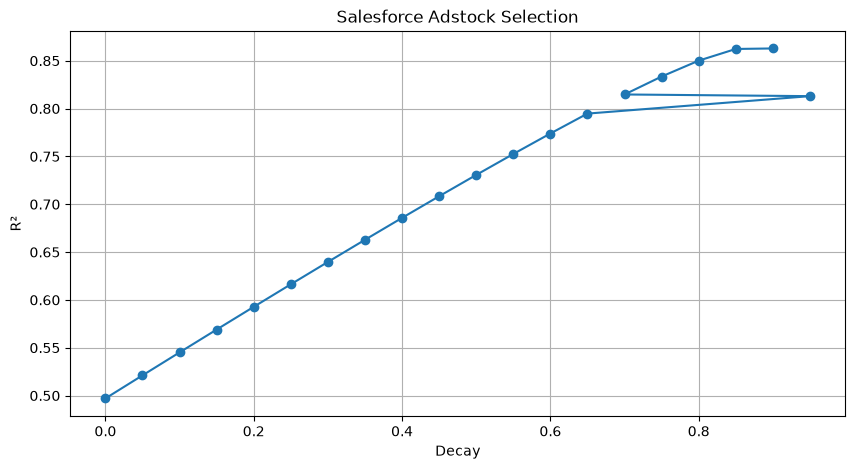

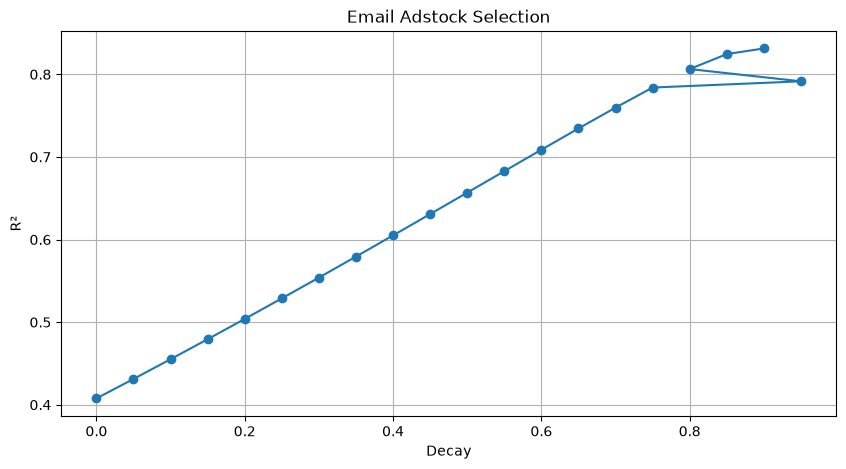

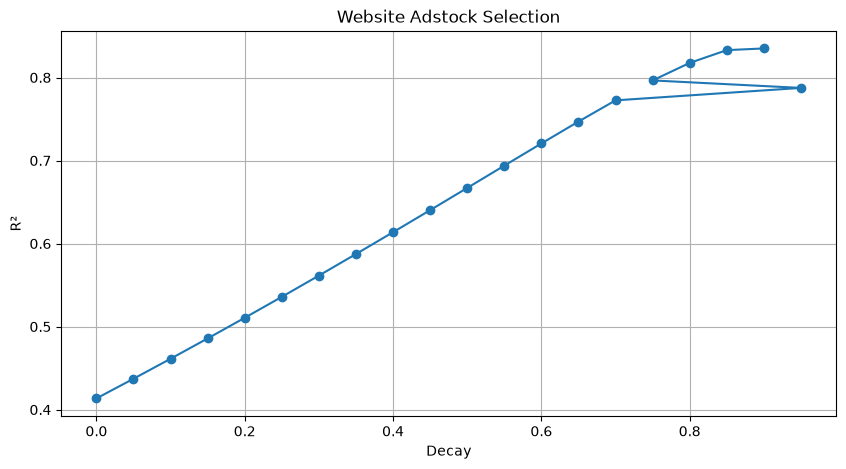

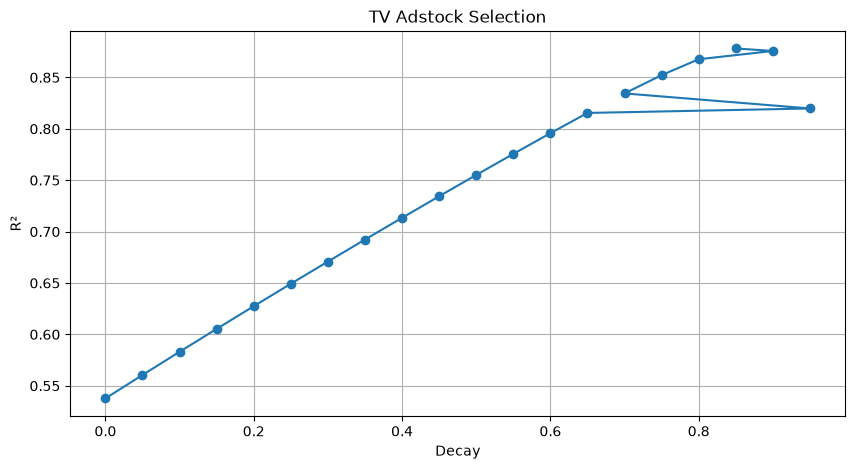

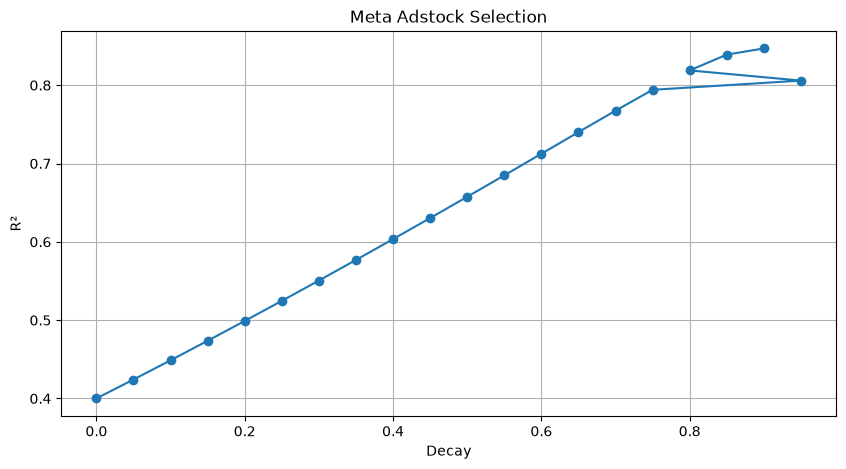

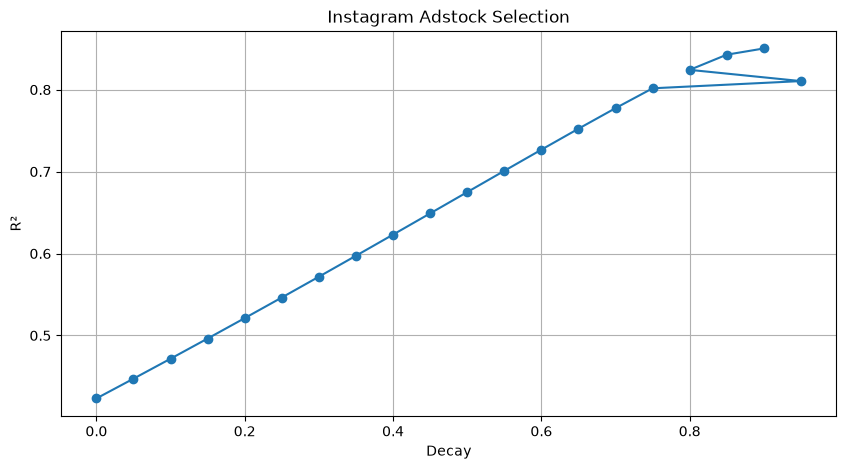

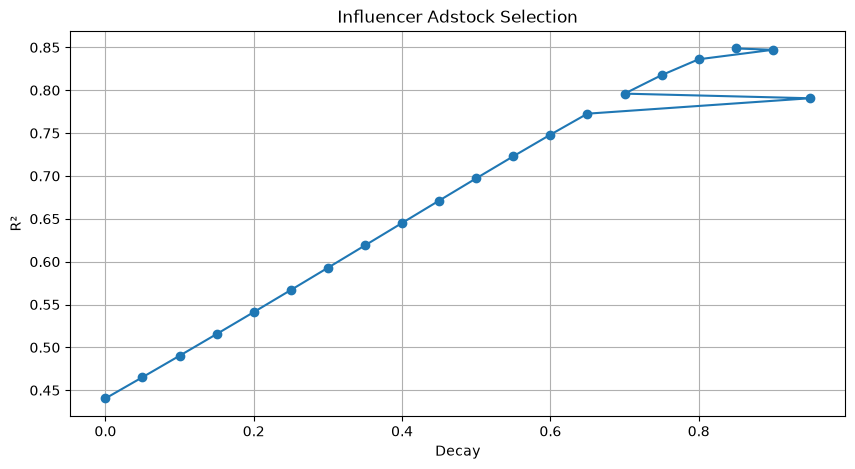

In [9]:
for channel in channels:

    results = all_results[channel]

    plt.figure(figsize=(10,5))

    plt.plot(
        results["Decay"],
        results["R2"],
        marker="o"
    )

    plt.title(f"{channel} Adstock Selection")

    plt.xlabel("Decay")

    plt.ylabel("R²")

    plt.grid(True)

    plt.show()

In [10]:
from pathlib import Path

output_folder = Path("../data/processed")

output_folder.mkdir(
    parents=True,
    exist_ok=True
)

best_adstock.to_csv(
    output_folder / "best_adstock.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.


In [11]:
best_adstock

,Channel,Best_Decay,R2,Adjusted_R2,RMSE,MAE,AIC,BIC
0,TV,0.85,0.878176,0.878148,128.736599,90.413216,42713.500194,42726.277095
1,Salesforce,0.90,0.862847,0.862816,136.595855,91.465695,43234.497902,43247.274803
2,Instagram,0.90,0.850273,0.850239,142.720204,99.513668,43620.110573,43632.887474
3,Influencer,0.85,0.848731,0.848697,143.453170,101.333895,43665.147958,43677.924858
4,Meta,0.90,0.846890,0.846855,144.323715,100.393732,43718.340956,43731.117856
5,Website,0.90,0.834999,0.834961,149.823253,100.206683,44047.139659,44059.916559
6,Email,0.90,0.831350,0.831311,151.470924,102.446857,44143.301276,44156.078177
